# **สร้าง mask ของรอยตำหนิ**

In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import defaultdict
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATAPATH = PROJECT_ROOT / "data" / "jpg"
MASKPATH = PROJECT_ROOT / "data" / "fruit_masks"
SAMPLES_PER_GRADE = 10
RANDOM_SEED = 42

DATAPATH.mkdir(parents=True, exist_ok=True)
MASKPATH.mkdir(parents=True, exist_ok=True)

In [24]:
jpg_img = list(DATAPATH.rglob("*.jpg"))
jpg_img

[WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (1).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (10).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (100).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (101).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (102).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (103).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (104).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (105).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (106).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (107).jpg'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/jpg/NDM_M1/NDM_M1 (108).jpg'),
 WindowsPath('c:/Users/noppa/OneDri

In [25]:
fruit_masks = list(MASKPATH.rglob("*.png"))
fruit_masks

[WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (1)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (10)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (100)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (101)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (102)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (103)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (104)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (105)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (106)_mask.png'),
 WindowsPath('c:/Users/noppa/OneDrive/Desktop/mango/data/fruit_masks/NDM_M1/NDM_M1 (107)_mask.

## ดึงเฉพาะตัวมะม่วง

In [26]:
images_by_grade = defaultdict(list)
for image_path in jpg_img:
    images_by_grade[image_path.parent.name].append(image_path)

masks_by_grade = defaultdict(list)
for mask_path in fruit_masks:
    masks_by_grade[mask_path.parent.name].append(mask_path)

In [27]:
masked_by_grade = defaultdict(list)

for (grade1, image_paths), (grade2, mask_paths) in zip(images_by_grade.items(), masks_by_grade.items()):
    for image_path, mask_path in zip(image_paths, mask_paths):
        img = plt.imread(image_path)
        fruit_mask = plt.imread(mask_path)

        masked_image = img.copy()
        masked_image[fruit_mask == 0] = 0

        masked_by_grade[grade1].append(masked_image)

        """
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(img)
        ax[0].set_title("Original")

        ax[1].imshow(fruit_mask, cmap="gray")
        ax[1].set_title("Fruit Mask")

        ax[2].imshow(masked_image)
        ax[2].set_title("Masked Fruit")
        """

masked_by_grade

defaultdict(list,
            {'NDM_M1': [array([[[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0],
                      ...,
                      [0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]],
              
                     [[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0],
                      ...,
                      [0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]],
              
                     [[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0],
                      ...,
                      [0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]],
              
                     ...,
              
                     [[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0],
                      ...,
                      [0, 0, 0],
                      [0, 0, 0],
                

In [28]:
rng = random.Random(RANDOM_SEED)
sampled_masked = {}
for grade in sorted(masked_by_grade):
    grade_images = masked_by_grade[grade]
    if len(grade_images) < SAMPLES_PER_GRADE:
        raise ValueError(
            f"เกรด {grade} มีรูปเพียง {len(grade_images)} รูป "
            f"ไม่ถึง {SAMPLES_PER_GRADE} รูป"
        )
    sampled_masked[grade] = rng.sample(grade_images, SAMPLES_PER_GRADE)

for grade, image_paths in sampled_masked.items():
    print(f"{grade}: {len(image_paths)} รูป")

sampled_masked

NDM_M1: 10 รูป
NDM_M2: 10 รูป
NDM_M3: 10 รูป


{'NDM_M1': [array([[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         ...,
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]]], shape=(1780, 1780, 3), dtype=uint8),
  array([[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
     

## แสดงรูปเฉพาะมะม่วง

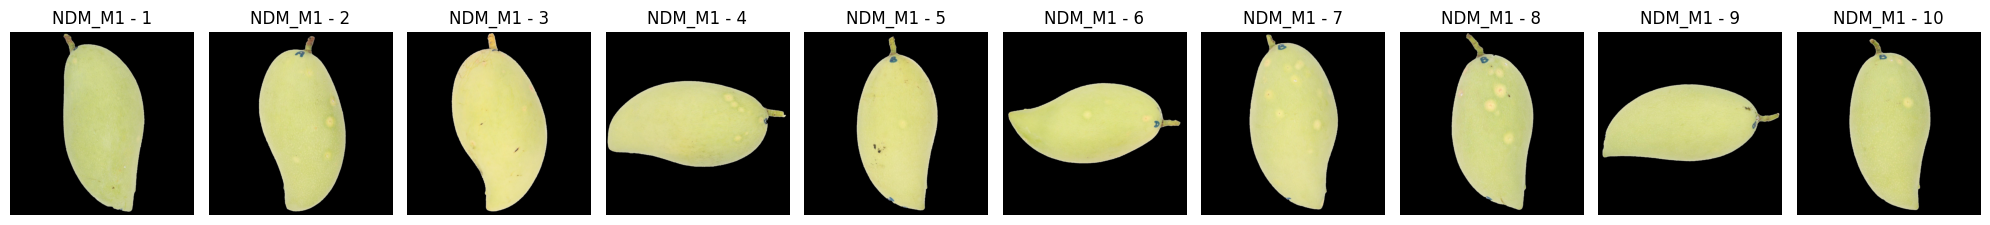

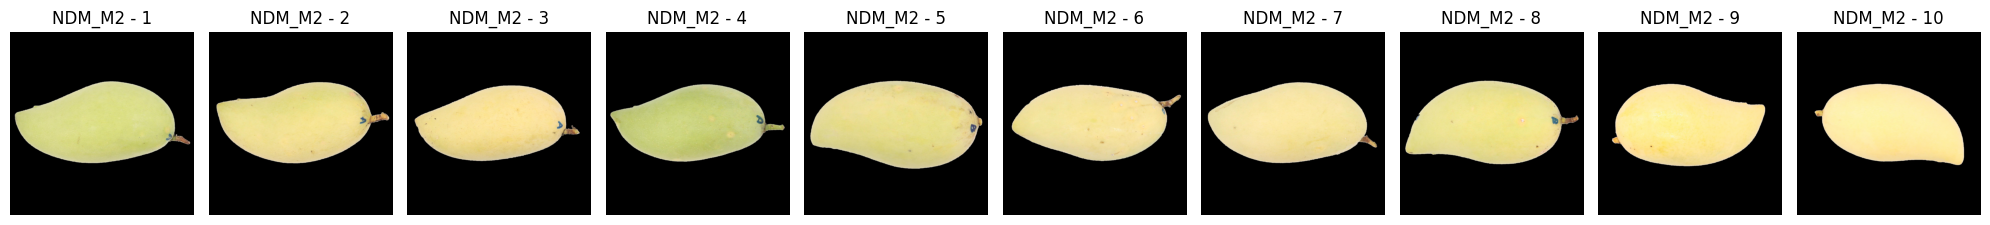

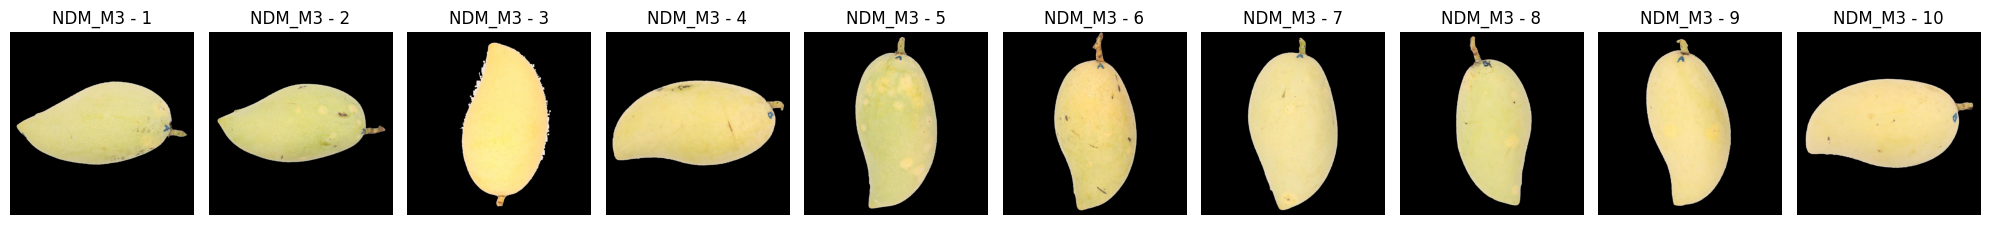

In [29]:
for grade, image_paths in sampled_masked.items():
    fig, ax = plt.subplots(1, SAMPLES_PER_GRADE, figsize=(20, 5))
    for i, image_path in enumerate(image_paths):
        ax[i].imshow(image_path)
        ax[i].axis("off")
        ax[i].set_title(f"{grade} - {i+1}")

    plt.tight_layout()
    plt.show()

## สร้าง defect mask จาก brightness histogram และตัดหมึกด้วย Hue

ขั้นตอนนี้ใช้ histogram เป็นวิธีหลัก โดยวิเคราะห์เฉพาะบริเวณมะม่วงจาก fruit mask และตัดพิกเซลที่มี Hue/Saturation เข้าข่ายหมึกออกก่อนสร้าง defect mask

In [30]:
DEFECT_MASKPATH = PROJECT_ROOT / "data" / "defect_masks"
DEFECT_MASKPATH.mkdir(parents=True, exist_ok=True)

import json

In [31]:
def mask_to_bboxes(defect_mask):
    contours, _ = cv2.findContours(
        defect_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    return [list(cv2.boundingRect(contour)) for contour in contours]


def histogram_defect_mask(image_path, fruit_mask_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    fruit_mask = cv2.imread(str(fruit_mask_path), cv2.IMREAD_GRAYSCALE)
    if image is None or fruit_mask is None:
        raise FileNotFoundError(f"ไม่พบภาพหรือ fruit mask ของ {image_path.stem}")

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hue, saturation, brightness = cv2.split(hsv_image)
    fruit_region = fruit_mask > 0
    if not np.any(fruit_region):
        raise ValueError(f"fruit mask ของ {image_path.stem} ไม่มีพิกเซล")

    local_background = cv2.GaussianBlur(brightness, (75, 75), 0)
    dark_residual = local_background.astype(np.int16) - brightness.astype(np.int16)

    ink_hue_low = 80
    ink_hue_high = 120
    ink_saturation_min = 50
    ink_mask = (
        fruit_region
        & (saturation >= ink_saturation_min)
        & (hue >= ink_hue_low)
        & (hue <= ink_hue_high)
    )

    yellow_hue_low = 28
    yellow_hue_high = 31
    yellow_saturation_min = 15
    yellow_mask = (
        fruit_region
        & (saturation >= yellow_saturation_min)
        & (hue >= yellow_hue_low)
        & (hue <= yellow_hue_high)
    )

    dark_values = np.clip(dark_residual[fruit_region & ~ink_mask & ~yellow_mask], 0, None)
    if dark_values.size == 0:
        defect_mask = np.zeros_like(brightness, dtype=np.uint8)
        return defect_mask, 0, yellow_mask.astype(np.uint8) * 255, ink_mask.astype(np.uint8) * 255

    defect_threshold, _ = cv2.threshold(
        dark_values.astype(np.uint8).reshape(-1, 1),
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU,
    )

    inner_region = cv2.erode(
        (fruit_region.astype(np.uint8) * 255),
        np.ones((20, 20), dtype=np.uint8),
    ) > 0

    candidate = (
        (dark_residual > max(20, int(defect_threshold)))
        & inner_region
        & ~ink_mask
        & ~yellow_mask
    )

    candidate = candidate.astype(np.uint8) * 255
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_OPEN, kernel_open)
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_CLOSE, kernel_close)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(candidate, connectivity=8)
    defect_mask = np.zeros_like(candidate, dtype=np.uint8)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if 80 <= area <= 8000:
            defect_mask[labels == label] = 255

    return defect_mask, int(defect_threshold), yellow_mask.astype(np.uint8) * 255, ink_mask.astype(np.uint8) * 255


In [32]:
image_paths = sorted(jpg_img)
metadata = []
missing_masks = []

for image_path in image_paths:
    grade = image_path.parent.name
    fruit_mask_path = MASKPATH / grade / f"{image_path.stem}_mask.png"
    if not fruit_mask_path.exists():
        missing_masks.append(str(fruit_mask_path))
        continue

    defect_mask, defect_threshold, yellow_mask, ink_mask = histogram_defect_mask(
        image_path,
        fruit_mask_path,
    )
    defect_mask_path = DEFECT_MASKPATH / grade / f"{image_path.stem}_defect.png"
    yellow_mask_path = DEFECT_MASKPATH / grade / f"{image_path.stem}_yellow.png"
    ink_mask_path = DEFECT_MASKPATH / grade / f"{image_path.stem}_ink.png"
    defect_mask_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(defect_mask_path), defect_mask)
    cv2.imwrite(str(yellow_mask_path), yellow_mask.astype(np.uint8) * 255)
    cv2.imwrite(str(ink_mask_path), ink_mask.astype(np.uint8) * 255)

    metadata.append(
        {
            "image_id": image_path.stem,
            "grade": grade,
            "image": str(image_path),
            "fruit_mask": str(fruit_mask_path),
            "defect_mask": str(defect_mask_path),
            "yellow_mask": str(yellow_mask_path),
            "ink_mask": str(ink_mask_path),
            "brightness_threshold": int(defect_threshold),
            "bboxes_xywh": mask_to_bboxes(defect_mask),
        }
    )

manifest_path = PROJECT_ROOT / "data" / "defect_manifest.json"
with manifest_path.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

print(f"สร้าง histogram defect mask แล้ว {len(metadata)} ภาพ")
print(f"บันทึก manifest ที่ {manifest_path}")
if missing_masks:
    print(f"ไม่พบ fruit mask จำนวน {len(missing_masks)} ภาพ")
metadata[:3]

สร้าง histogram defect mask แล้ว 542 ภาพ
บันทึก manifest ที่ c:\Users\noppa\OneDrive\Desktop\mango\data\defect_manifest.json


[{'image_id': 'NDM_M1 (1)',
  'grade': 'NDM_M1',
  'image': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\jpg\\NDM_M1\\NDM_M1 (1).jpg',
  'fruit_mask': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\fruit_masks\\NDM_M1\\NDM_M1 (1)_mask.png',
  'defect_mask': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\defect_masks\\NDM_M1\\NDM_M1 (1)_defect.png',
  'yellow_mask': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\defect_masks\\NDM_M1\\NDM_M1 (1)_yellow.png',
  'ink_mask': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\defect_masks\\NDM_M1\\NDM_M1 (1)_ink.png',
  'brightness_threshold': 22,
  'bboxes_xywh': [[552, 1077, 16, 11],
   [1672, 909, 34, 12],
   [1551, 894, 39, 50],
   [1430, 892, 37, 56]]},
 {'image_id': 'NDM_M1 (10)',
  'grade': 'NDM_M1',
  'image': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\jpg\\NDM_M1\\NDM_M1 (10).jpg',
  'fruit_mask': 'c:\\Users\\noppa\\OneDrive\\Desktop\\mango\\data\\fruit_masks\\NDM_M1\\NDM_M1 (10)_mask.png',
  'defect_mask':

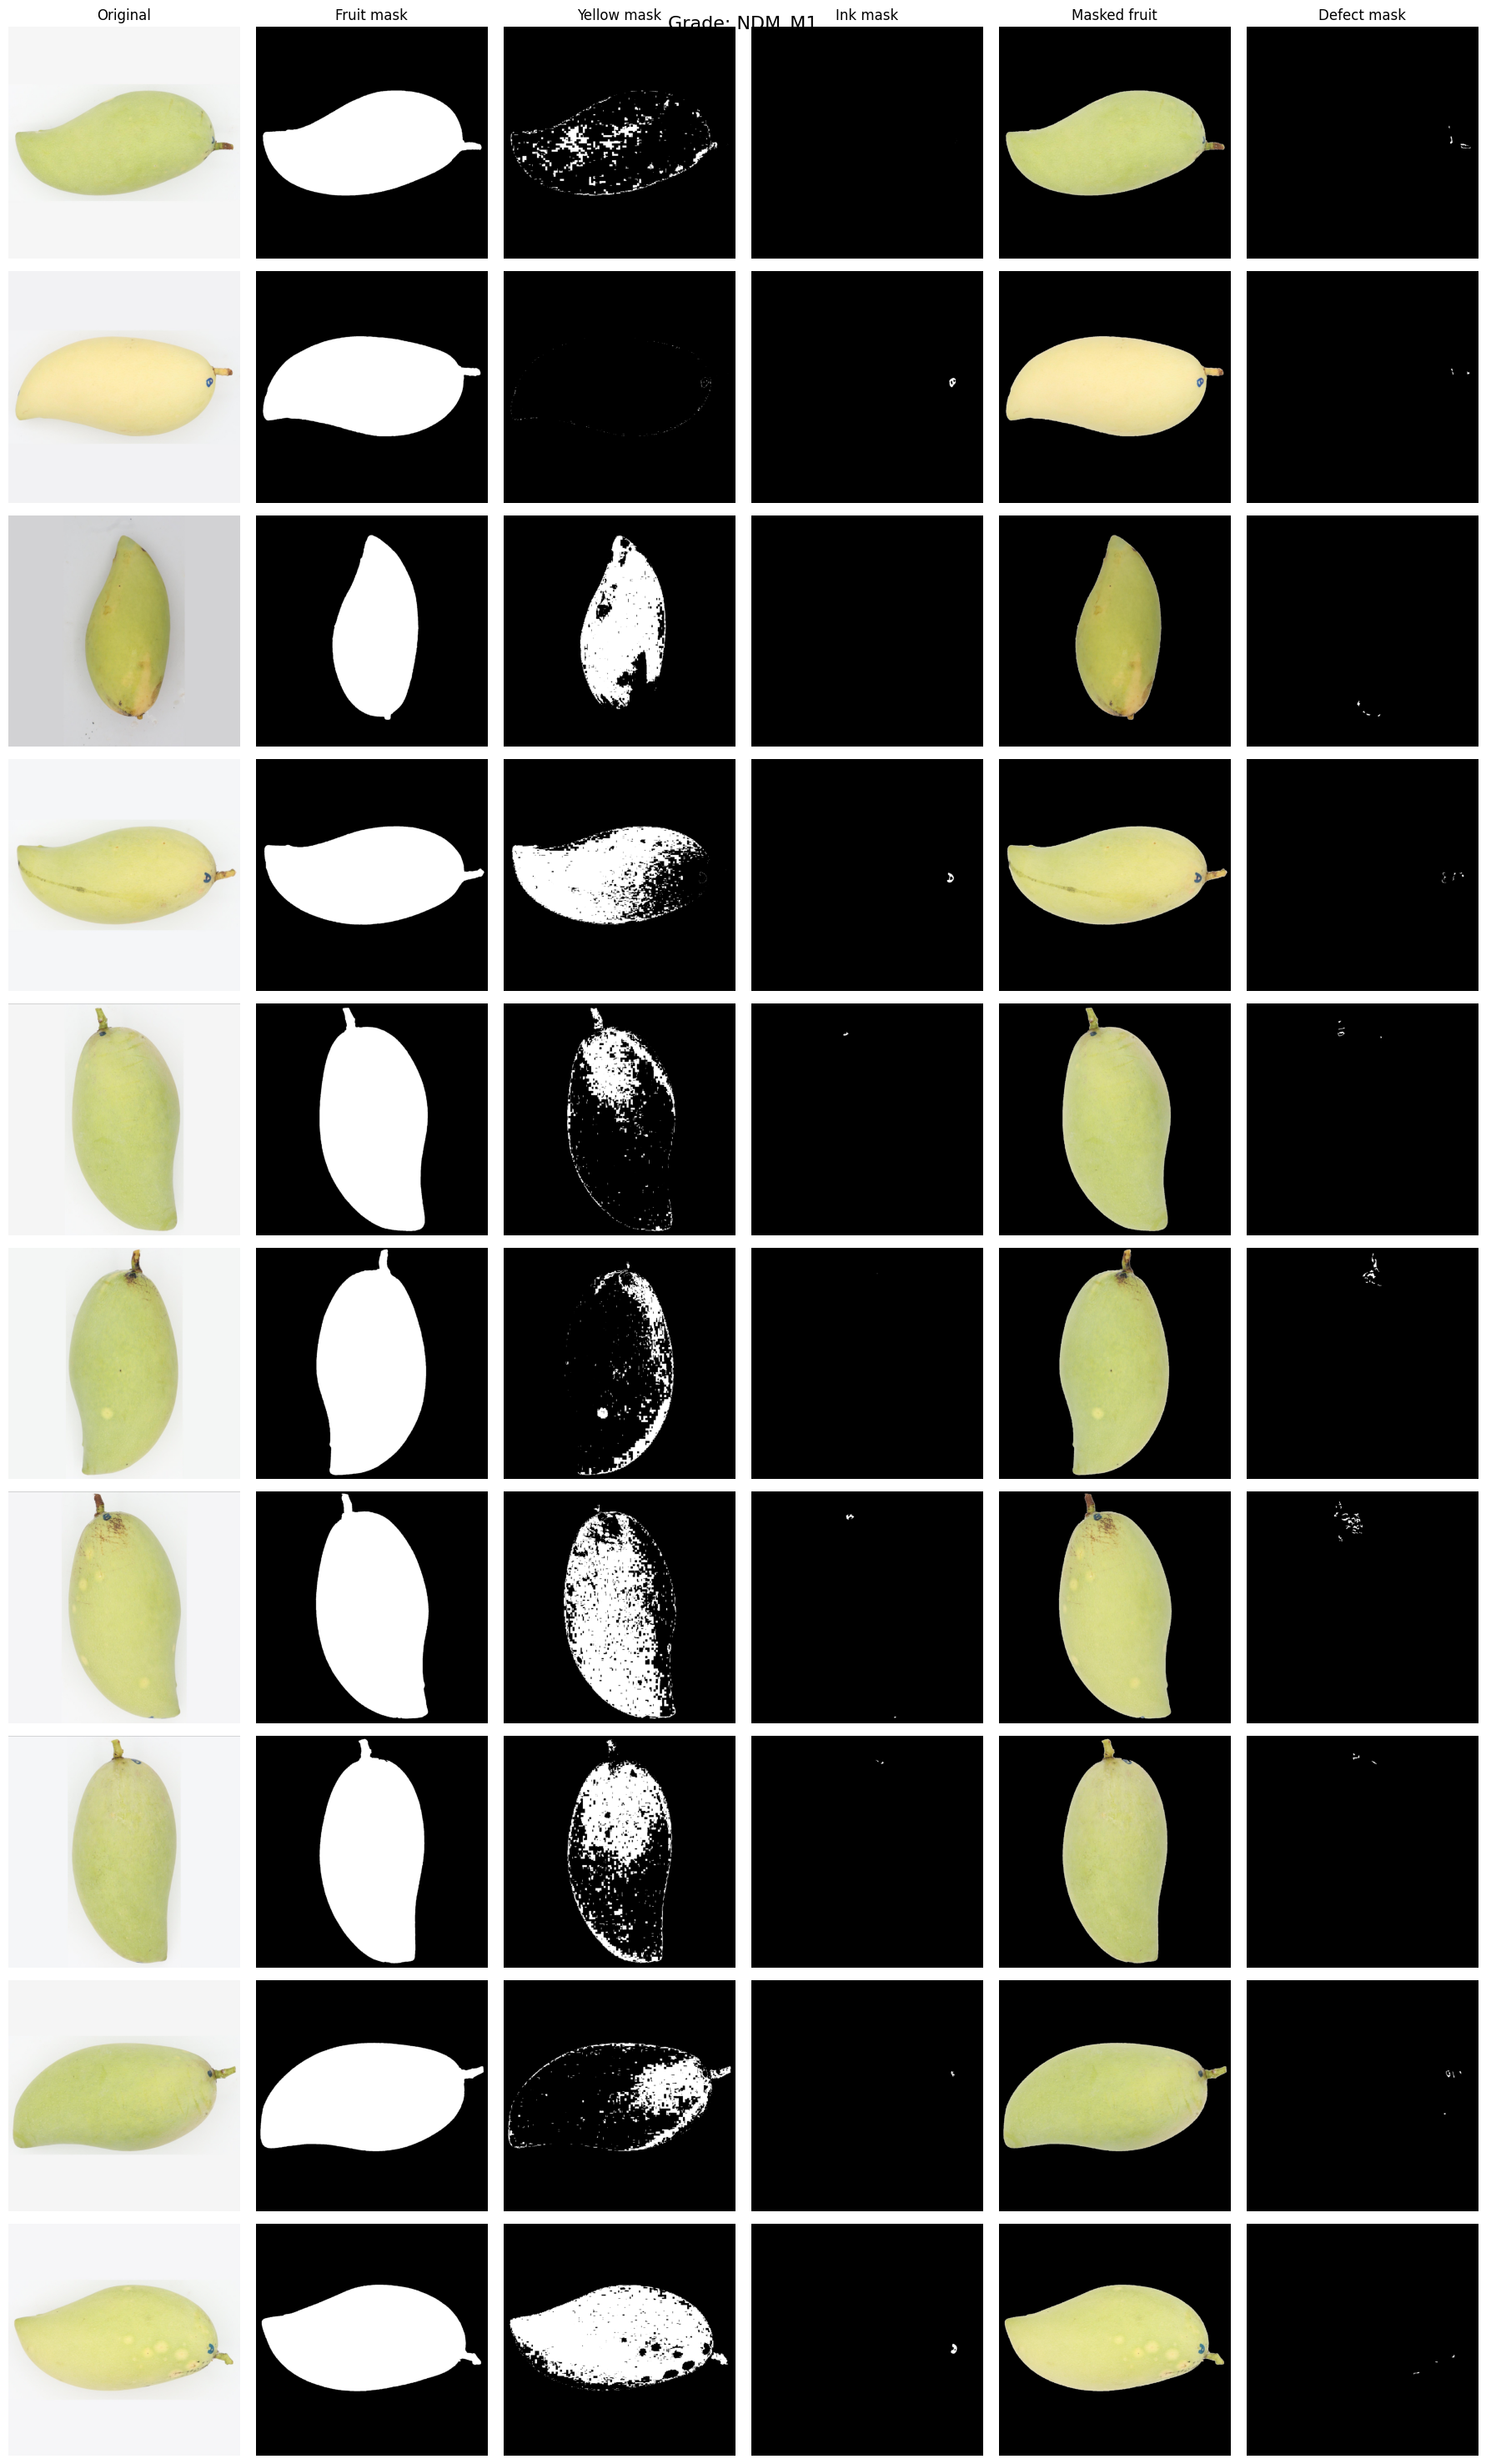

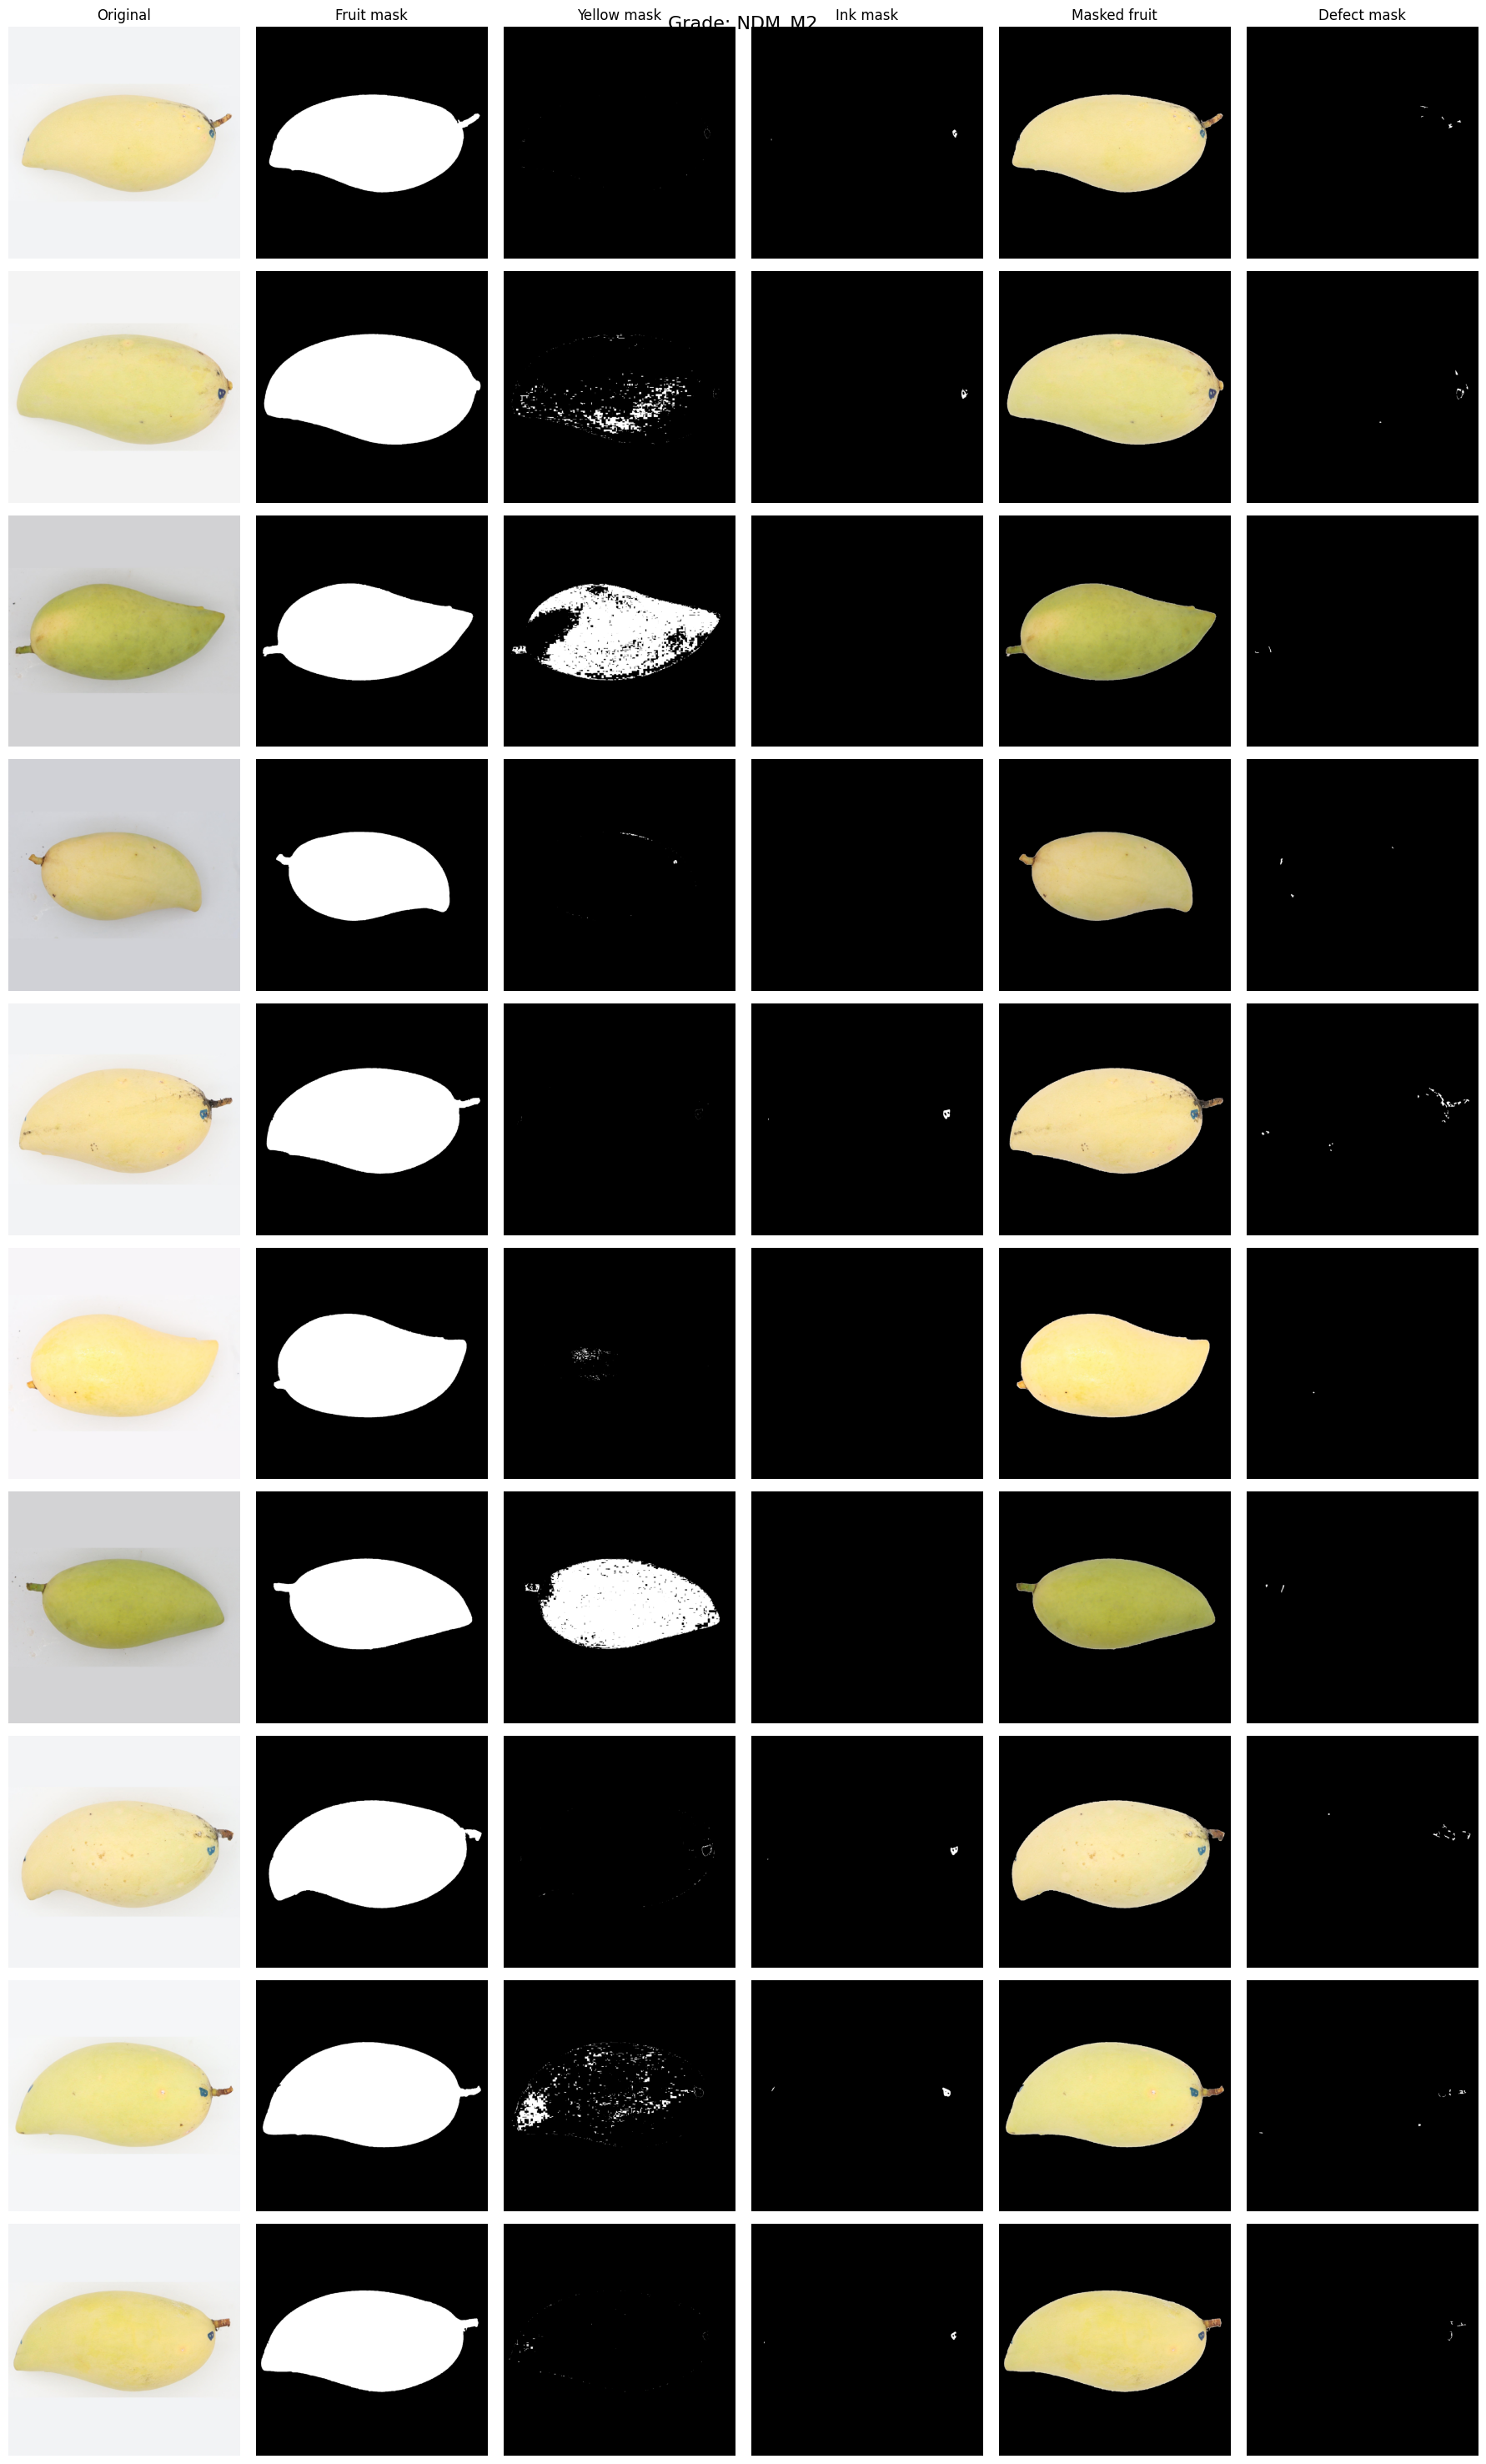

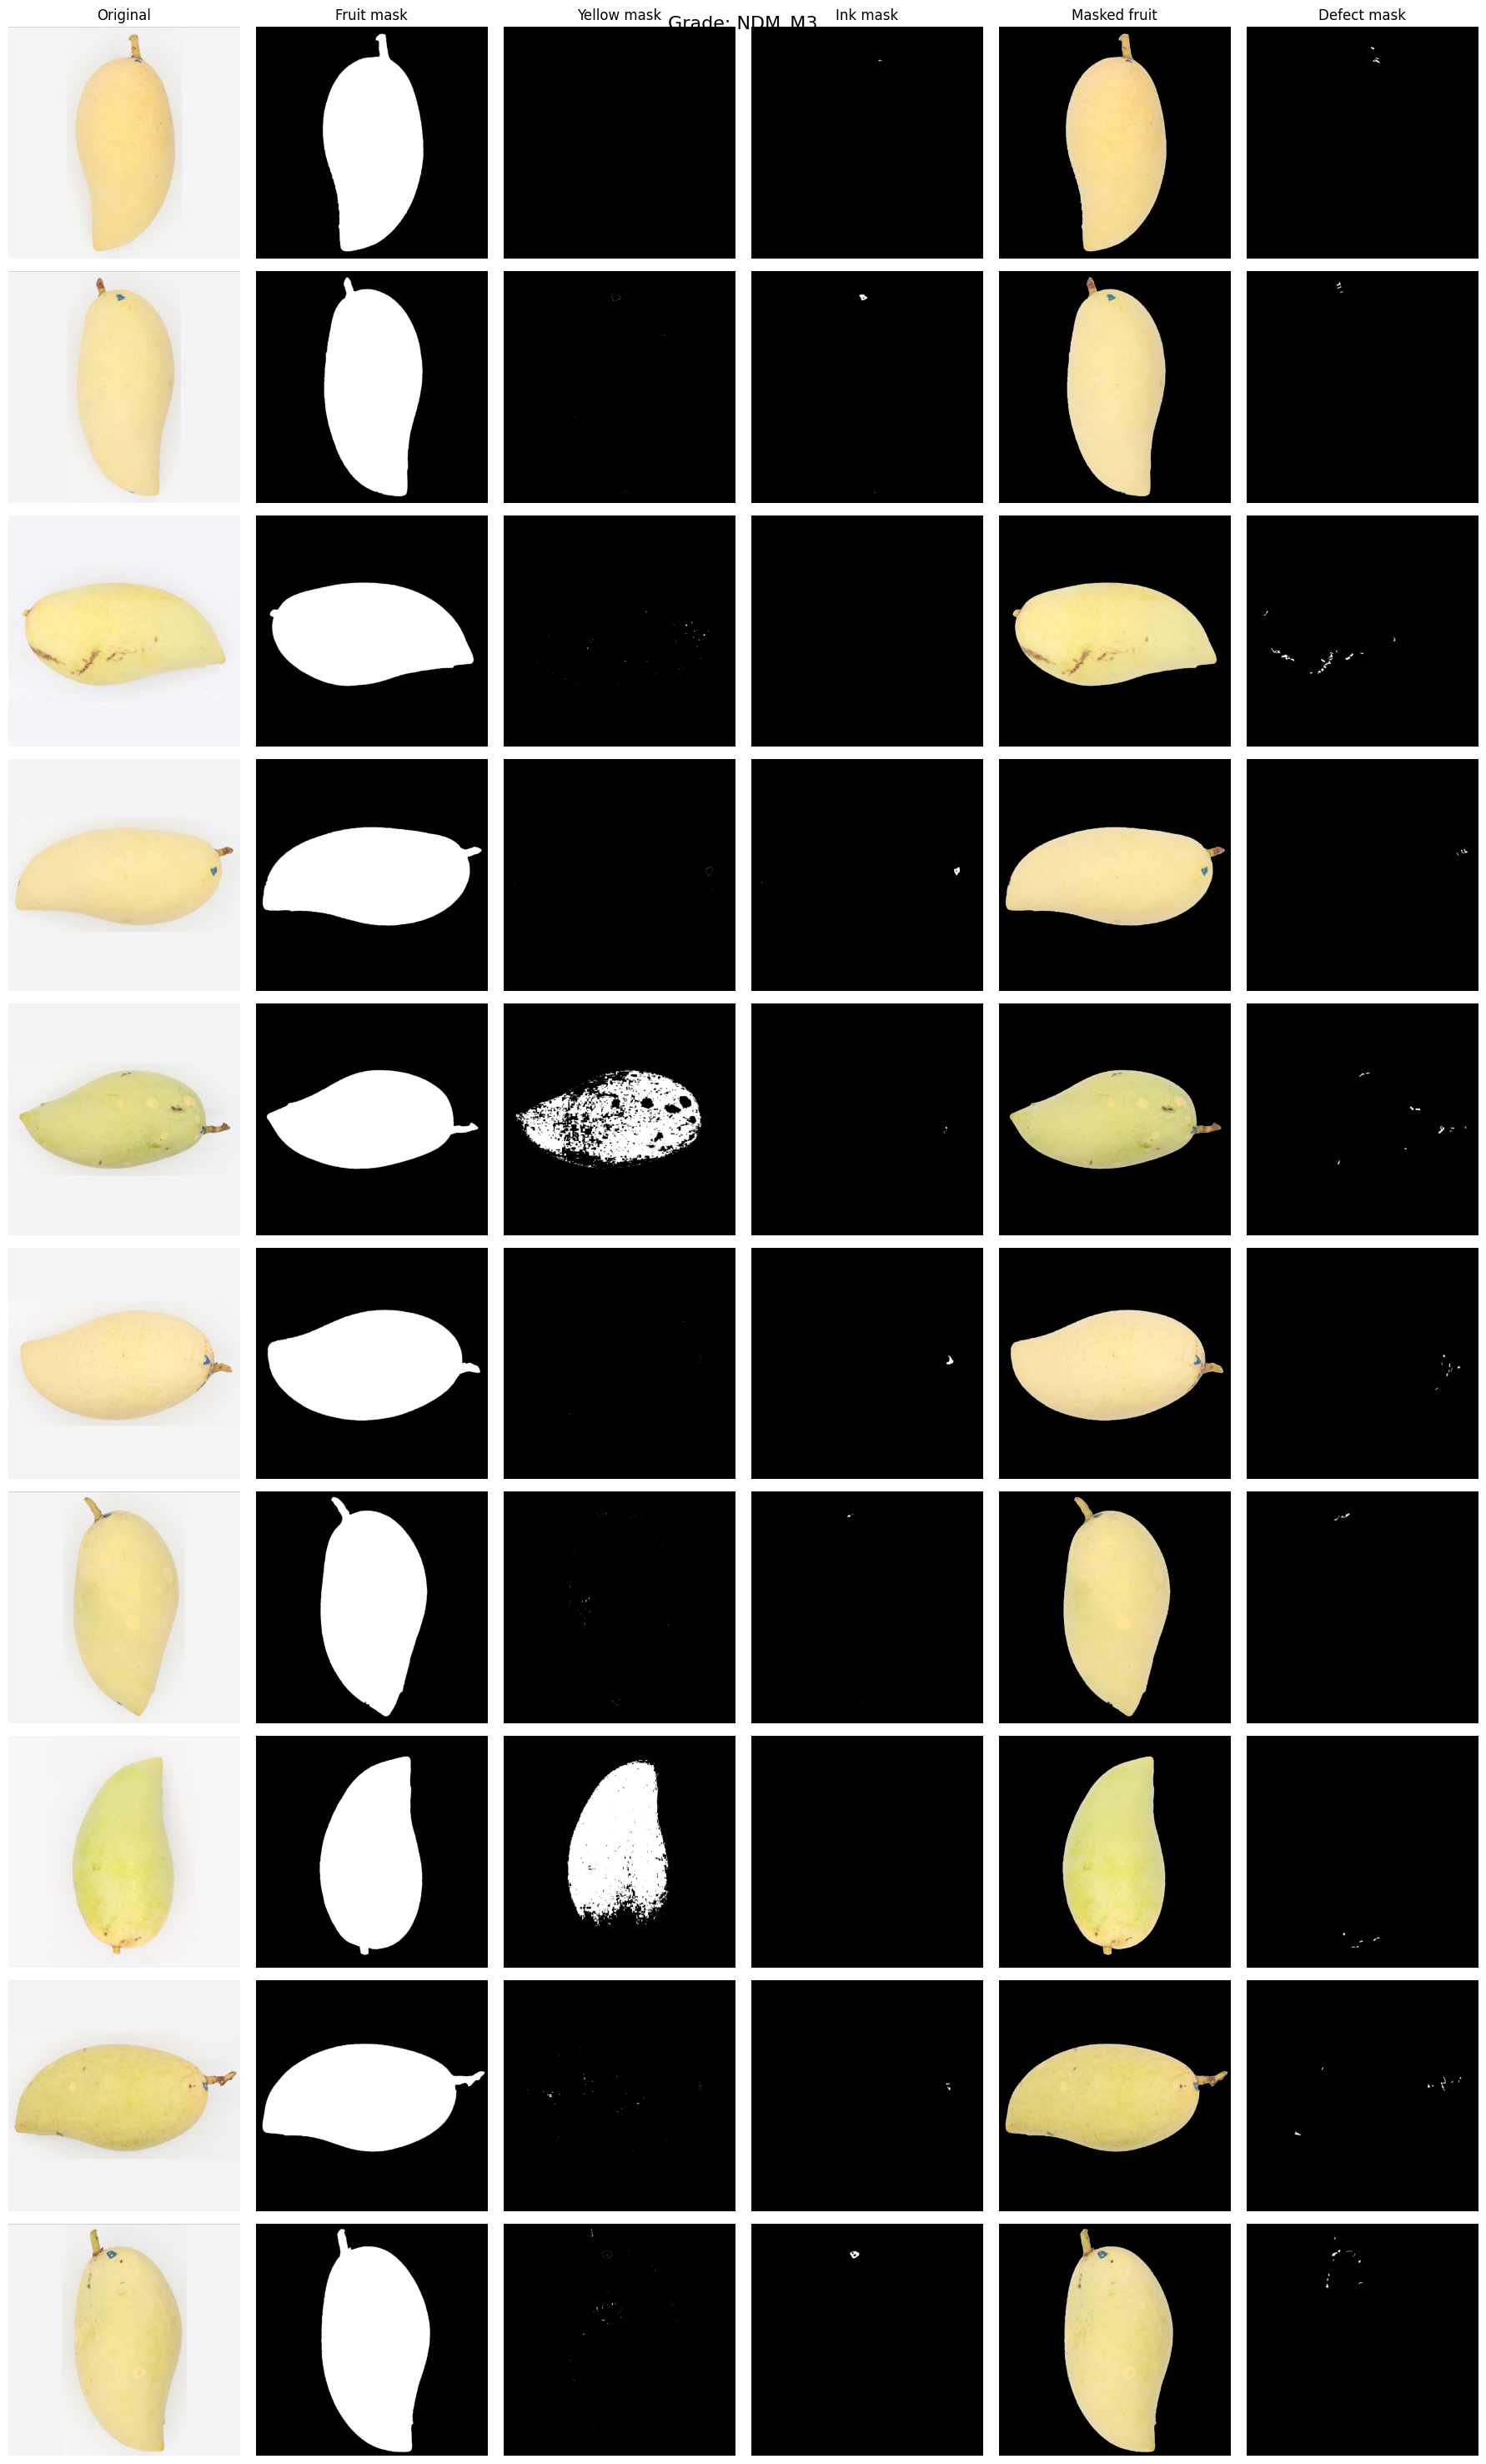

In [33]:
# สุ่มและแสดงภาพเกรดละ 10 รูป พร้อม mask แต่ละประเภท
metadata_by_grade = defaultdict(list)
for item in metadata:
    metadata_by_grade[item["grade"]].append(item)

for grade in sorted(metadata_by_grade):
    items = metadata_by_grade[grade]

    if len(items) < SAMPLES_PER_GRADE:
        print(f"ข้ามเกรด {grade}: มีเพียง {len(items)} รูป")
        continue

    samples = rng.sample(items, SAMPLES_PER_GRADE)
    fig, axes = plt.subplots(
        SAMPLES_PER_GRADE, 6,
        figsize=(18, 3 * SAMPLES_PER_GRADE),
    )

    fig.suptitle(f"Grade: {grade}", fontsize=16)

    for row, item in enumerate(samples):
        image = cv2.cvtColor(
            cv2.imread(item["image"]),
            cv2.COLOR_BGR2RGB
        )
        fruit_mask = cv2.imread(item["fruit_mask"], cv2.IMREAD_GRAYSCALE)
        defect_mask = cv2.imread(item["defect_mask"], cv2.IMREAD_GRAYSCALE)
        yellow_mask = cv2.imread(item["yellow_mask"], cv2.IMREAD_GRAYSCALE)
        ink_mask = cv2.imread(item["ink_mask"], cv2.IMREAD_GRAYSCALE)

        masked_fruit = image.copy()
        masked_fruit[fruit_mask == 0] = 0

        images = [
            image,
            fruit_mask,
            yellow_mask,
            ink_mask,
            masked_fruit,
            defect_mask,
        ]
        titles = [
            "Original",
            "Fruit mask",
            "Yellow mask",
            "Ink mask",
            "Masked fruit",
            "Defect mask",
        ]

        for col, (display_image, title) in enumerate(zip(images, titles)):
            cmap = "gray" if display_image.ndim == 2 else None
            axes[row, col].imshow(display_image, cmap=cmap)
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(title)

    plt.tight_layout()
    plt.show()